# 05. SHAP Explainability

Notebook ini menjelaskan hasil prediksi model ANN (yang bersifat *black-box*) menggunakan **SHAP (SHapley Additive exPlanations)**, dalam dua bentuk: *global explanation* (fitur paling berpengaruh secara keseluruhan) dan *local explanation* (penjelasan untuk satu nasabah tertentu).

**Pipeline notebook:** `00_Data_Exploration` → `01_Data_Preprocessing` → `02_Feature_Engineering` → `03_Modeling_ANN` → `04_Training_Evaluation` → `05_SHAP_Explainability` → `06_Deployment`

Formulasi SHAP: f(x) = E[f(x)] + Σφᵢ, dengan f(x) adalah hasil prediksi model, E[f(x)] adalah nilai dasar (baseline) prediksi, dan φᵢ adalah kontribusi fitur ke-i terhadap prediksi.

---

## Import Library

In [1]:
import sys, os
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import tensorflow as tf
from tensorflow import keras

from io_utils import DATA_PROCESSED, MODELS, REPORTS, load_json

shap.initjs()
np.random.seed(42)

## Memuat Model Terbaik & Data

In [2]:
selected_features = load_json('selected_features.json')
label_names = {int(k): v for k, v in load_json('label_names.json').items()}
best_model_info = load_json('best_model_info.json')

model = keras.models.load_model(os.path.join(MODELS, 'best_model.keras'))

test_df = pd.read_parquet(os.path.join(DATA_PROCESSED, 'test.parquet'))
X_test = test_df[selected_features]
y_test = test_df['risk_class']

print(f'Model terbaik: {best_model_info["best_exp_id"]} '
      f'({best_model_info["config"]["description"]})')
print(f'Data uji untuk SHAP: {X_test.shape}')

Model terbaik: E6 (ANN + Dropout + Class Weight)
Data uji untuk SHAP: (133107, 15)


## Membangun SHAP Explainer

Karena model berupa Keras `Model` dengan output Softmax multikelas, digunakan `shap.Explainer` berbasis *permutation* dengan fungsi `model.predict` dan latar belakang (*background*) berupa sampel acak dari data train, agar komputasi tetap efisien untuk dataset besar.

In [3]:
# Background sample (representatif, tidak perlu seluruh data train)
background = shap.sample(X_test, 100, random_state=42)

def predict_fn(x):
    return model.predict(np.asarray(x), verbose=0)
 
explainer = shap.Explainer(predict_fn, background, feature_names=selected_features)

# Ambil sampel evaluasi (subset test set) agar komputasi SHAP wajar durasinya
sample_eval = shap.sample(X_test, 200, random_state=42)
shap_values = explainer(sample_eval)

print('SHAP values shape:', shap_values.values.shape)

PermutationExplainer explainer: 201it [15:29,  4.65s/it]                         

SHAP values shape: (200, 15, 4)


## Global Explanation

Menampilkan fitur yang paling berpengaruh secara keseluruhan terhadap prediksi tiap kelas risiko kredit.

C:\Users\Yosua Triantara\AppData\Local\Temp\ipykernel_6056\4159392022.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


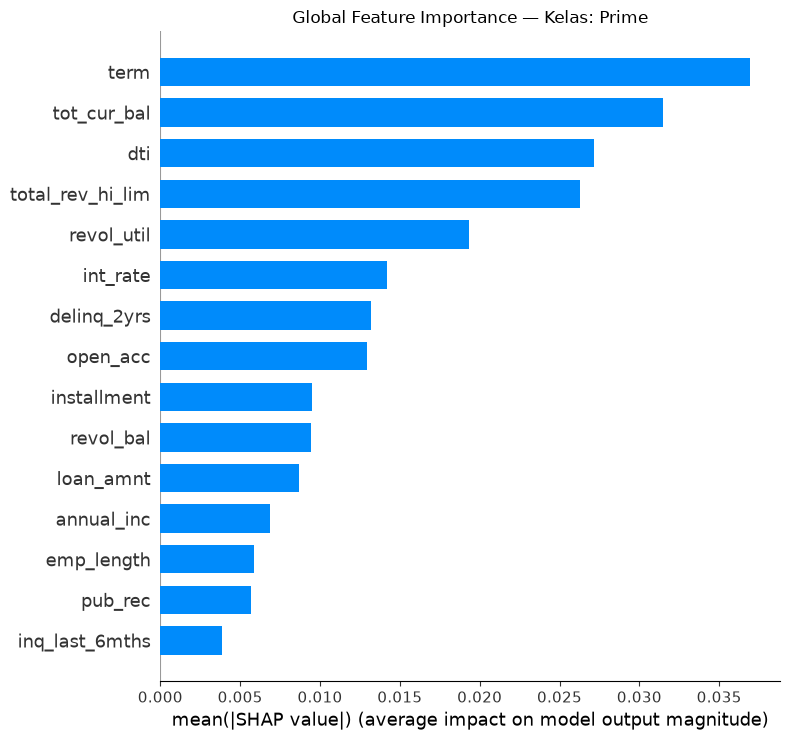

C:\Users\Yosua Triantara\AppData\Local\Temp\ipykernel_6056\4159392022.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


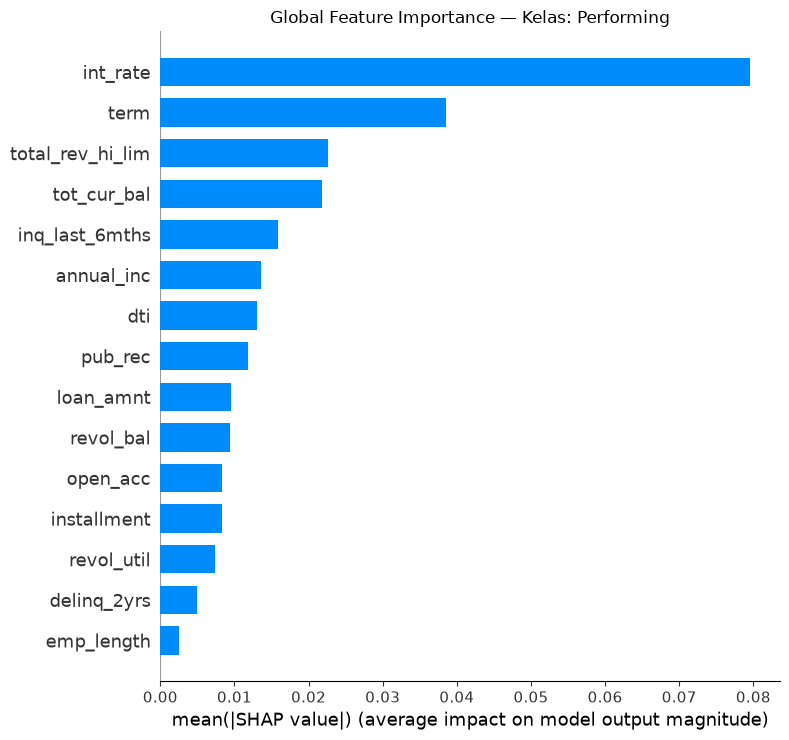

C:\Users\Yosua Triantara\AppData\Local\Temp\ipykernel_6056\4159392022.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


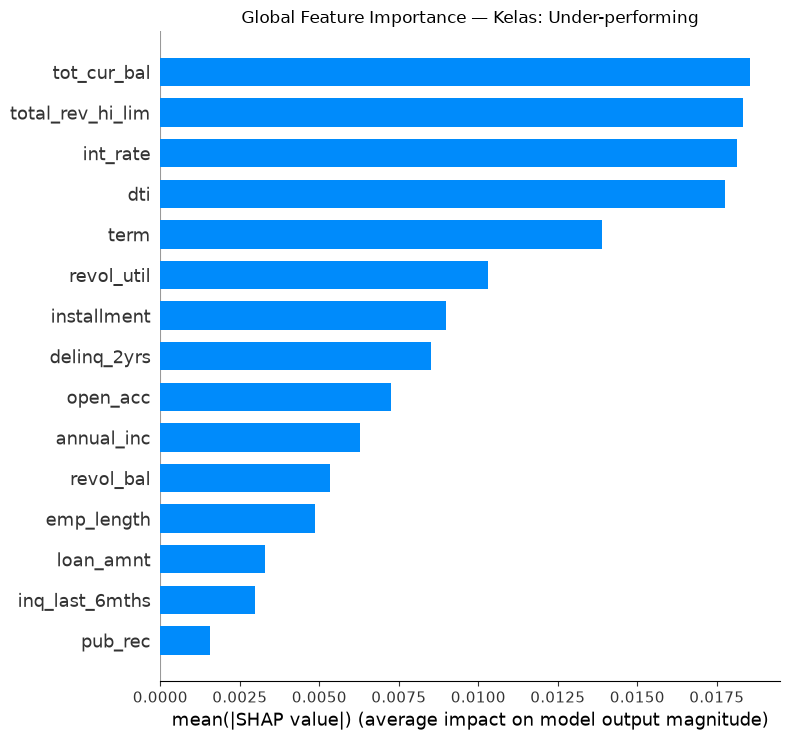

C:\Users\Yosua Triantara\AppData\Local\Temp\ipykernel_6056\4159392022.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


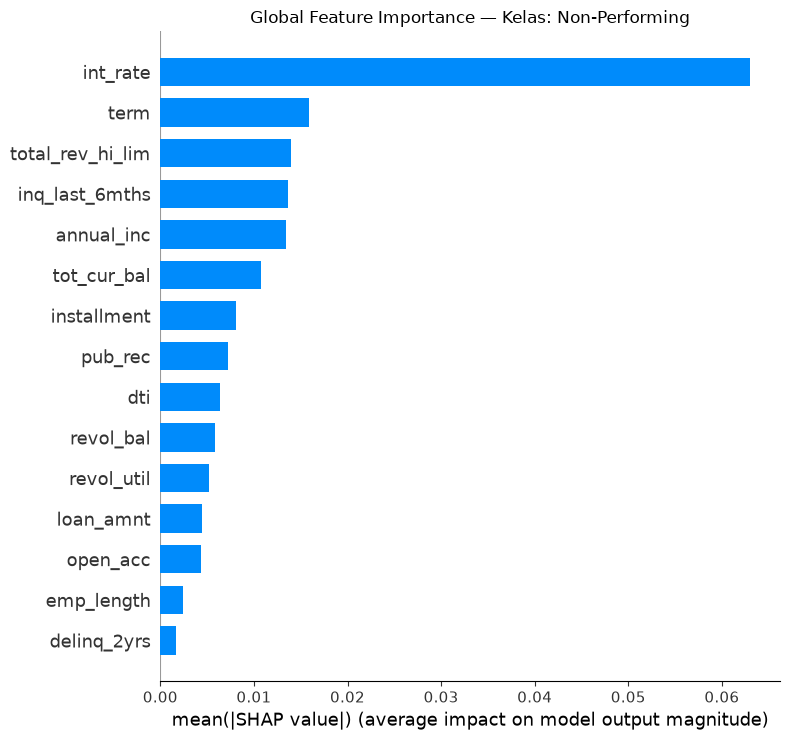

In [ ]:
os.makedirs(os.path.join(REPORTS, 'shap'), exist_ok=True)

for class_idx, class_name in label_names.items():
    plt.figure()
    shap.summary_plot(
        shap_values[:, :, class_idx].values,
        sample_eval,
        feature_names=selected_features,
        show=False,
        plot_type='bar',
    )
    plt.title(f'Global Feature Importance — Kelas: {class_name}')
    plt.tight_layout()
    plt.savefig(
        os.path.join(REPORTS, 'shap', f'global_importance_{class_name}.png'),
        dpi=120,
    )
    plt.show()

C:\Users\Yosua Triantara\AppData\Local\Temp\ipykernel_6056\1151030092.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


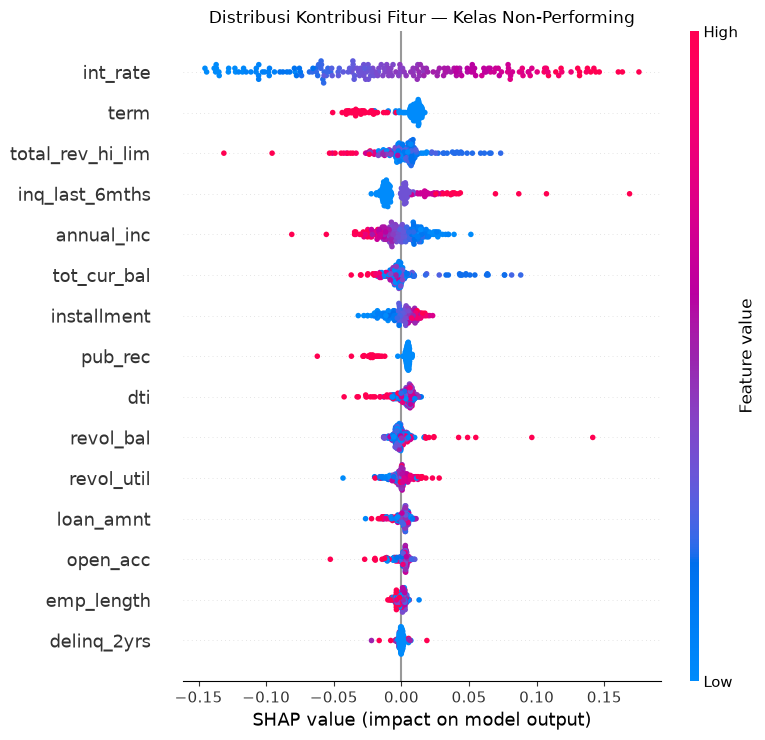

In [8]:
# Beeswarm plot untuk kelas Non-Performing (kelas risiko tertinggi)
non_performing_idx = [k for k, v in label_names.items() if v == 'Non-Performing'][0]

plt.figure()
shap.summary_plot(
    shap_values[:, :, non_performing_idx].values,
    sample_eval,
    feature_names=selected_features,
    show=False,
)
plt.title('Distribusi Kontribusi Fitur — Kelas Non-Performing')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'shap', 'beeswarm_non_performing.png'), dpi=120)
plt.show()

## Local Explanation

Menjelaskan prediksi untuk satu nasabah tertentu — nilai SHAP positif mendorong prediksi ke kelas tersebut, nilai negatif menurunkan kemungkinan prediksi pada kelas tersebut.

Prediksi untuk nasabah index 0: Performing
Probabilitas per kelas:
  Prime: 0.279
  Performing: 0.306
  Under-performing: 0.238
  Non-Performing: 0.177


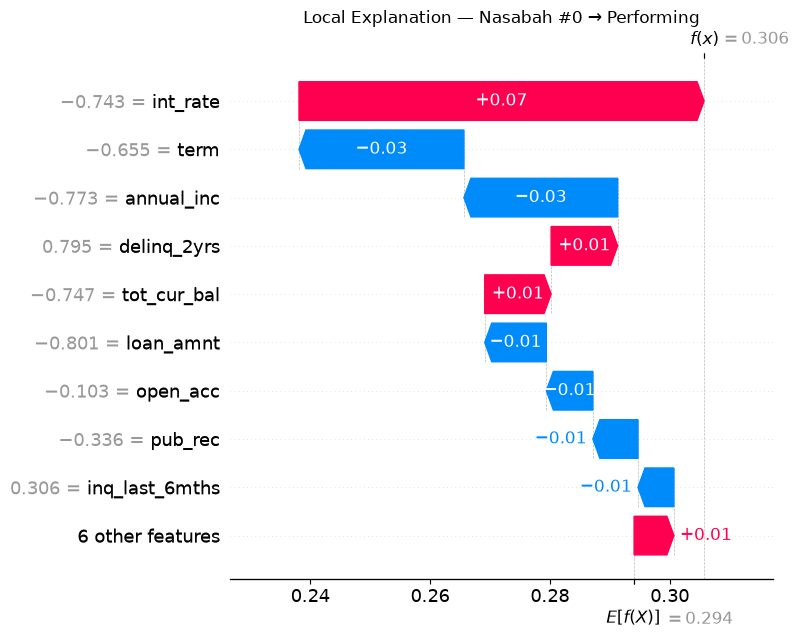

In [9]:
sample_idx = 0  # ganti index untuk melihat nasabah lain
customer = sample_eval.iloc[[sample_idx]]
pred_proba = model.predict(customer.values, verbose=0)[0]
pred_class = int(np.argmax(pred_proba))

print(f'Prediksi untuk nasabah index {sample_idx}: {label_names[pred_class]}')
print('Probabilitas per kelas:')
for k, v in label_names.items():
    print(f'  {v}: {pred_proba[k]:.3f}')

plt.figure()
shap.plots.waterfall(shap_values[sample_idx, :, pred_class], show=False)
plt.title(f'Local Explanation — Nasabah #{sample_idx} → {label_names[pred_class]}')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'shap', f'local_explanation_{sample_idx}.png'), dpi=120)
plt.show()

## Ringkasan & Langkah Selanjutnya

SHAP memberikan interpretasi  (fitur mana yang paling mendorong risiko kredit secara umum) maupun spesifik per nasabah, sehingga model ANN yang awalnya *black-box* menjadi lebih dapat dipertanggungjawabkan